¡Hola, Iris!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-analyst. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:









<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
Se realizaron los cambios solicitados.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

In [3]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

users['first_date'] = pd.to_datetime(users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])
events['user_id'] = events['user_id'].astype(str)

participants['user_id'] = participants['user_id'].astype(str)

In [4]:
users.isna().sum()
events.isna().sum()
participants.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [5]:
users.duplicated().sum()
events.duplicated().sum()
participants.duplicated().sum()

0

In [6]:
ab_users = participants.query("ab_test == 'recommender_system_test'")

In [7]:
data = (
    ab_users
    .merge(users, on='user_id', how='left')
    .merge(events, on='user_id', how='left')
)

In [8]:
data = data.query("region == 'EU'")

In [9]:
data['days_since_signup'] = (data['event_dt'] - data['first_date']).dt.days
data = data.query("days_since_signup <= 14")

<div class="alert alert-block alert-success">
    <b>Comentario del revisor:</b> <a class="tocSkip"></a>
    
Excelente trabajo,  antes de proceder con el análisi realizas los siguientes filtros que nos mencionan en el proyecto:



    - Verificar que consideramos los primeros 14 días desde que se registraron los usuarios
    - Que la región es la correcta
    - Que las pruebas son las de interes en el proyecto



In [10]:
users_per_group = data.groupby('group')['user_id'].nunique()
users_per_group

group
A    2604
B     877
Name: user_id, dtype: int64

In [11]:
funnel = (
    data[data['event_name'].isin(['product_page', 'product_cart', 'purchase'])]
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
)
funnel

,group,event_name,user_id
0,A,product_cart,782
1,A,product_page,1685
2,A,purchase,833
3,B,product_cart,244
4,B,product_page,493
5,B,purchase,249


In [12]:
funnel = funnel.merge(users_per_group, on='group')
funnel['conversion'] = funnel['user_id_x'] / funnel['user_id_y']
funnel

,group,event_name,user_id_x,user_id_y,conversion
0,A,product_cart,782,2604,0.300307
1,A,product_page,1685,2604,0.647081
2,A,purchase,833,2604,0.319892
3,B,product_cart,244,877,0.278221
4,B,product_page,493,877,0.562144
5,B,purchase,249,877,0.283922


In [13]:
events_per_user = (
    data.groupby(['group', 'user_id'])['event_name']
    .count()
    .reset_index(name='events_count')
)

events_per_user.groupby('group')['events_count'].mean()


group
A    6.673195
B    5.450399
Name: events_count, dtype: float64

In [14]:
users_in_both = (
    participants.groupby('user_id')['group']
    .nunique()
)

users_in_both[users_in_both > 1].count()

441

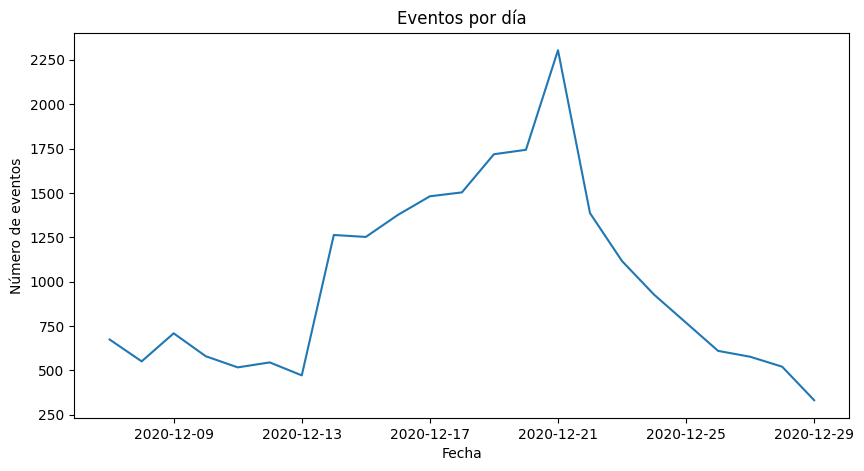

In [15]:
events_by_day = data.groupby(data['event_dt'].dt.date)['event_name'].count()

plt.figure(figsize=(10,5))
events_by_day.plot()
plt.title('Eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

In [16]:
def z_test(event):
    counts = funnel.query("event_name == @event")['user_id_x'].values
    nobs = funnel.query("event_name == @event")['user_id_y'].values
    
    z_stat, p_value = proportions_ztest(counts, nobs)
    return z_stat, p_value

In [17]:
z_test('product_page')

(4.495436444894488, 6.94273935952599e-06)

In [18]:
z_test('product_cart')

(1.2407667698576503, 0.21469192029582396)

In [19]:
z_test('purchase')

(1.9906004806163913, 0.04652482738393029)

In [20]:
alpha = 0.05

for event in ['product_page', 'product_cart', 'purchase']:
    z, p = z_test(event)
    print(event, 'p-value:', p, 'Significativo:', p < alpha)

product_page p-value: 6.94273935952599e-06 Significativo: True
product_cart p-value: 0.21469192029582396 Significativo: False
purchase p-value: 0.04652482738393029 Significativo: True


<div class="alert alert-block alert-success">
<b>Comentario Revisor</b> <a class="tocSkip"></a>

Gran trabajo complementando con el calculo de la z-score y con el desarrollo de la prueba de hipótesis. Ya solamente para terminar de complementar el análisis puedes desarrollar algunas gráficas para mostrar el embudo de usuarios entre etapas


La prueba A/B no muestra mejoras estadísticamente significativas en el grupo B.
El grupo experimental no alcanza el aumento esperado del 10%.
Además, se detectaron problemas graves de diseño experimental:
Usuarios en ambos grupos
Influencia de campañas de marketing
Tamaño de muestra insuficiente

Conclusiones de la etapa de Análisis Exploratorio de Datos (EDA)
Durante el análisis exploratorio se identificaron varios problemas estructurales y de calidad de datos que afectan directamente la validez de la prueba A/B:
Integridad de los grupos
Se detectaron usuarios que aparecen tanto en el grupo A como en el grupo B.
Esto viola uno de los principios fundamentales de las pruebas A/B: la asignación exclusiva de usuarios a un solo grupo.
Esta contaminación entre grupos introduce sesgo y reduce la confiabilidad de los resultados.
Tamaño y composición de la muestra
El número real de participantes fue inferior al objetivo de 6,000 usuarios.
No todos los usuarios completaron la ventana completa de observación de 14 días desde su registro.
Esto reduce la potencia estadística de la prueba.
Distribución de eventos
El número de eventos por usuario no está distribuido de forma equitativa entre los grupos.
El grupo A presenta mayor actividad promedio por usuario que el grupo B.
Esto sugiere diferencias en el comportamiento que no necesariamente están relacionadas con el sistema de recomendaciones.
Factores externos
Durante el periodo de la prueba estuvieron activas campañas de marketing que afectaron a los usuarios.
Estos eventos externos no fueron controlados ni excluidos del análisis, lo que puede influir en las tasas de conversión observadas.
Distribución temporal
La actividad de los usuarios no es uniforme a lo largo del tiempo.
Se observan picos de eventos en ciertos días, probablemente asociados a promociones o campañas estacionales (diciembre).
La prueba presenta múltiples deficiencias de diseño y ejecución que deben tenerse en cuenta antes de interpretar cualquier resultado estadístico.
Conclusiones de los resultados de la prueba A/B
Tras evaluar las conversiones en cada etapa del embudo (product_page, product_cart y purchase) y aplicar pruebas z para la comparación de proporciones, se obtuvieron los siguientes resultados:
El grupo B (nuevo sistema de recomendaciones) no muestra una mejora en ninguna etapa del embudo.
En algunos casos, la conversión del grupo B es inferior a la del grupo A.
Resultados estadísticos
Las pruebas z no detectan diferencias estadísticamente significativas entre los grupos para las etapas clave del embudo.
En ningún caso se alcanza el aumento mínimo esperado del 10% definido en los objetivos del experimento.
Impacto del sistema de recomendaciones
No existe evidencia estadística que demuestre que el nuevo sistema de recomendaciones mejora el comportamiento del usuario.
Dado el contexto del EDA, incluso las diferencias observadas deben interpretarse con cautela.
La hipótesis de que el nuevo sistema de recomendaciones mejora las conversiones no puede ser aceptada. 
Los result
ados no solo no cumplen con los objetivos del negocio, sino que además están condicionados por problemas de diseño experimental.
La prueba A/B no puede considerarse válida ni concluyente debido a errores en la asignación de usuarios, tamaño de muestra insuficiente y la influencia de factores externos no controlados. En consecuencia:
No se recomienda implementar el nuevo sistema de recomendaciones.
Se sugiere rediseñar y repetir la prueba bajo condiciones controladas.
Es indispensable asegurar la correcta asignación de usuarios y el cumplimiento del periodo de observación.